DBSCAN Cluster Count:
 0    4231
-1      76
 1       5
Name: count, dtype: int64
DBSCAN Silhouette Score: 0.8838128428277037


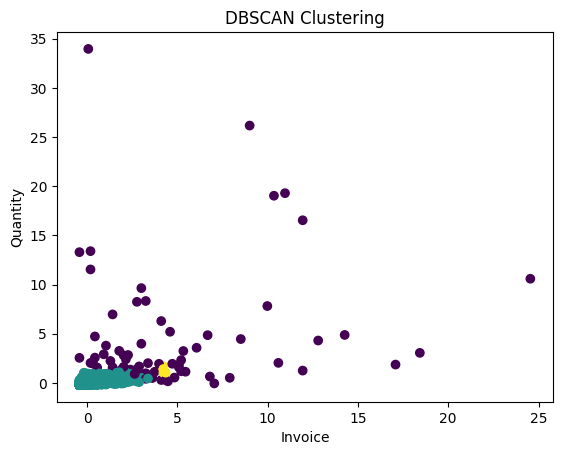

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Load data
df = pd.read_excel("online_retail_II.xlsx",
                   sheet_name="Year 2009-2010")

# Clean data
df = df.dropna(subset=["Customer ID"])
df = df[~df["Invoice"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

# Total amount
df["TotalAmount"] = df["Quantity"] * df["Price"]

# Customer data
customer = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "Quantity": "sum",
    "TotalAmount": "sum"
})

# Features
X = customer[
    ["Invoice", "Quantity", "TotalAmount"]
]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
model = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = model.fit_predict(X_scaled)

print("DBSCAN Cluster Count:")
print(pd.Series(labels).value_counts())

# Silhouette score
valid = labels != -1

if len(set(labels[valid])) > 1:
    score = silhouette_score(
        X_scaled[valid],
        labels[valid]
    )
    print("DBSCAN Silhouette Score:", score)

# Plot
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels
)

plt.xlabel("Invoice")
plt.ylabel("Quantity")
plt.title("DBSCAN Clustering")
plt.show()